In [8]:
import numpy as np
import pandas as pd

In [9]:
data = pd.read_csv("/content/Tweets.csv")
data

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative
...,...,...,...,...
27476,4eac33d1c0,wish we could come see u on Denver husband l...,d lost,negative
27477,4f4c4fc327,I`ve wondered about rake to. The client has ...,", don`t force",negative
27478,f67aae2310,Yay good for both of you. Enjoy the break - y...,Yay good for both of you.,positive
27479,ed167662a5,But it was worth it ****.,But it was worth it ****.,positive


In [10]:
data.shape

(27481, 4)

In [11]:
data.size

109924

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


In [13]:
data = data.drop(['textID'], axis=1, errors='ignore')

In [14]:
data.isnull().sum()

,0
text,1
selected_text,1
sentiment,0


In [15]:
data.dropna(inplace=True)
data.isnull().sum()

,0
text,0
selected_text,0
sentiment,0


In [16]:
data['text']=data['text'].str.strip()
data['selected_text']=data['selected_text'].str.strip()
data['sentiment']=data['sentiment'].str.strip()

In [17]:
for col in data.select_dtypes(include='object').columns:
    data[col]=data[col].str.lower()
data.head()

,text,selected_text,sentiment
0,"i`d have responded, if i were going","i`d have responded, if i were going",neutral
1,sooo sad i will miss you here in san diego!!!,sooo sad,negative
2,my boss is bullying me...,bullying me,negative
3,what interview! leave me alone,leave me alone,negative
4,"sons of ****, why couldn`t they put them on th...","sons of ****,",negative


In [18]:
data=data.drop_duplicates()
data.shape

(27429, 3)

In [19]:
data['sentiment'].value_counts()

,count
sentiment,
neutral,11102
positive,8552
negative,7775


In [20]:
data['text']=data['text'].str.replace(r'<[^<>]*>', '', regex=True)
data['selected_text']=data['selected_text'].str.replace(r'<[^<>]*>','',regex=True)
data['text']=data['text'].str.replace(r'http\S+', '', regex=True)
data['selected_text']=data['selected_text'].str.replace(r'http\S+','',regex=True)
data.head()

,text,selected_text,sentiment
0,"i`d have responded, if i were going","i`d have responded, if i were going",neutral
1,sooo sad i will miss you here in san diego!!!,sooo sad,negative
2,my boss is bullying me...,bullying me,negative
3,what interview! leave me alone,leave me alone,negative
4,"sons of ****, why couldn`t they put them on th...","sons of ****,",negative


In [21]:
l=['`','~','!','@','#','$','%','^','&','*','(',')','-','_','=','+','[','{',']','}','|',';',':','"',"'",',','<','.','>','/','?']
for i in l:
    data['text']=data['text'].str.replace(i, '')
    data['selected_text']=data['selected_text'].str.replace(i, '')
data.head()

,text,selected_text,sentiment
0,id have responded if i were going,id have responded if i were going,neutral
1,sooo sad i will miss you here in san diego,sooo sad,negative
2,my boss is bullying me,bullying me,negative
3,what interview leave me alone,leave me alone,negative
4,sons of why couldnt they put them on the rele...,sons of,negative


In [22]:
data['text']=data['text'].str.replace(r'[^a-zA-Z0-9\s]', '', regex=True)
data['selected_text']=data['selected_text'].str.replace(r'[^a-zA-Z0-9\s]','',regex=True)

In [23]:
cw=['a ','and','be','do','for','have','my','the','to']
for k in cw:
    data['text'] = data['text'].str.replace(k, '')
    data['selected_text']=data['selected_text'].astype(str).str.replace(k, '')

In [24]:
import spacy
nlp = spacy.load('en_core_web_sm')
def lemmatize_with_spacy(text):
    doc = nlp(text)
    return [token.lemma_ for token in doc]
data['text']=data['text'].apply(lemmatize_with_spacy)
data['selected_text']=data['selected_text'].apply(lemmatize_with_spacy)

In [25]:
data.head()

,text,selected_text,sentiment
0,"[I, d, , respond, if, I, be, go]","[I, d, , respond, if, I, be, go]",neutral
1,"[sooo, sad, I, will, miss, you, here, in, san,...","[sooo, sad]",negative
2,"[ , boss, be, bully, I]","[bully, I]",negative
3,"[what, interview, leave, I, alone]","[leave, I, alone]",negative
4,"[son, of, , why, could, not, y, put, m, on, ...","[son, of]",negative


In [26]:
data['positive']=data['sentiment'].apply(lambda x: 1 if x=='positive' else 0)
data['negative']=data['sentiment'].apply(lambda x: 1 if x=='negative' else 0)
data['neutral']=data['sentiment'].apply(lambda x: 1 if x=='neutral' else 0)
data.head()

,text,selected_text,sentiment,positive,negative,neutral
0,"[I, d, , respond, if, I, be, go]","[I, d, , respond, if, I, be, go]",neutral,0,0,1
1,"[sooo, sad, I, will, miss, you, here, in, san,...","[sooo, sad]",negative,0,1,0
2,"[ , boss, be, bully, I]","[bully, I]",negative,0,1,0
3,"[what, interview, leave, I, alone]","[leave, I, alone]",negative,0,1,0
4,"[son, of, , why, could, not, y, put, m, on, ...","[son, of]",negative,0,1,0


In [27]:
from sklearn.model_selection import train_test_split
X=data['selected_text'].astype('str')
y=data[['positive', 'negative', 'neutral']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)
y_train_labels = y_train.idxmax(axis=1)
y_test_labels = y_test.idxmax(axis=1)

In [28]:

from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)
from sklearn.ensemble import RandomForestClassifier
rf_classifier = RandomForestClassifier()
rf_classifier.fit(X_tfidf, y_train_labels)

RandomForestClassifier()

In [29]:
from sklearn.metrics import accuracy_score
predictions = rf_classifier.predict(X_test_tfidf)
accuracy = accuracy_score(y_test_labels, predictions)
print(f"Model Accuracy: {accuracy}")

Model Accuracy: 0.8058694859642727


In [30]:
param_grid = {
    'n_estimators': 100,
    'max_depth': None,
    'min_samples_split': 2,
    'min_samples_leaf': 1
}
param_rf_classifier = RandomForestClassifier(
    n_estimators=param_grid['n_estimators'],
    max_depth=param_grid['max_depth'],
    min_samples_split=param_grid['min_samples_split'],
    min_samples_leaf=param_grid['min_samples_leaf']
)
param_rf_classifier.fit(X_tfidf, y_train_labels)

RandomForestClassifier()

In [31]:
y_pred_labels = param_rf_classifier.predict(X_test_tfidf)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test_labels, y_pred_labels)
print(f"Overall Accuracy: {accuracy:.2f}")

Overall Accuracy: 0.81


In [32]:
sample=["It was amazing to work with you.",
     "Time and tide waits for none!",
    "I hate you! Get lost from here."
]
t=tfidf_vectorizer.transform(sample)
rf_classifier.predict(t)

array(['neutral', 'neutral', 'neutral'], dtype=object)

In [33]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test_labels, y_pred_labels)
print("Confusion Matrix: ")
print(cm)

Confusion Matrix: 
[[1191  320   43]
 [ 198 1969   95]
 [ 137  272 1261]]


Text(58.222222222222214, 0.5, 'Truth')

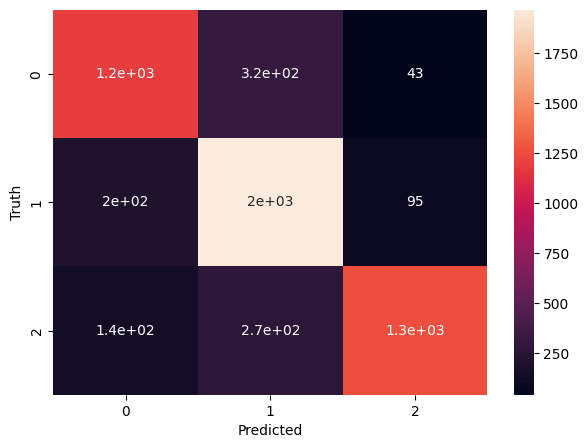

In [34]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sn
plt.figure(figsize=(7,5))
sn.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

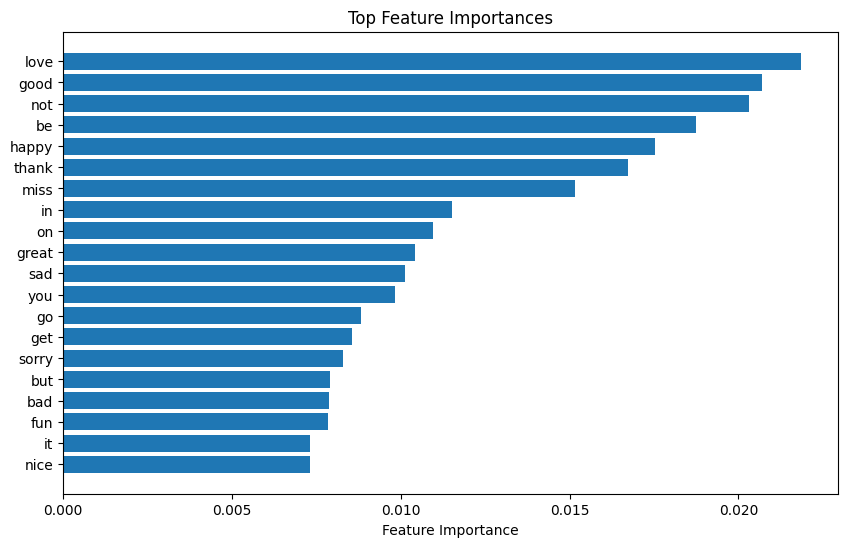

In [35]:
importances = param_rf_classifier.feature_importances_
feature_names = tfidf_vectorizer.get_feature_names_out()
sorted_indices = importances.argsort()[::-1]
top_n = 20
top_features = feature_names[sorted_indices[:top_n]]
top_importances = importances[sorted_indices[:top_n]]
plt.figure(figsize=(10, 6))
plt.barh(range(top_n), top_importances, align='center')
plt.yticks(range(top_n), top_features)
plt.xlabel('Feature Importance')
plt.title('Top Feature Importances')
plt.gca().invert_yaxis()
plt.show()

<Figure size 800x600 with 0 Axes>

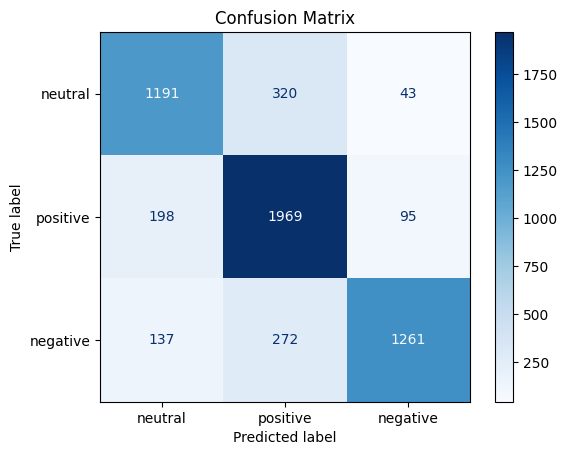

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test_labels, param_rf_classifier.predict(X_test_tfidf))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_test_labels.unique())
plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='.0f')
plt.title('Confusion Matrix')
plt.show()

In [37]:
from sklearn.metrics import classification_report
print("Classification Report: ")
print(classification_report(y_test_labels, y_pred_labels))

Classification Report: 
              precision    recall  f1-score   support

    negative       0.78      0.77      0.77      1554
     neutral       0.77      0.87      0.82      2262
    positive       0.90      0.76      0.82      1670

    accuracy                           0.81      5486
   macro avg       0.82      0.80      0.80      5486
weighted avg       0.81      0.81      0.81      5486



In [68]:
# Custom tweets you want to predict
sample_texts = [
    "I love you!",
    "Worst experience ever",
    "The service is okay",
    "Amazing update from the company! Really great!",
    "I hate waiting so long…",
    "I am going...",
    "Good morning",
    "who are you...?",
    "Nice to meet you",
    "Haaaaaaaa....",
    "smile"

]

# 1. Transform using trained TF-IDF
sample_tfidf = tfidf_vectorizer.transform(sample_texts)

# 2. Predict sentiment
sample_preds = rf_classifier.predict(sample_tfidf)

# 3. Print in clean required format
print("\n--- Final Tweet Sentiment Predictions ---\n")
for idx, (text, pred) in enumerate(zip(sample_texts, sample_preds)):
    print(f"{idx:<3} {text:<55} {pred}")



--- Final Tweet Sentiment Predictions ---

0   I love you!                                             positive
1   Worst experience ever                                   negative
2   The service is okay                                     neutral
3   Amazing update from the company! Really great!          positive
4   I hate waiting so long…                                 negative
5   I am going...                                           neutral
6   Good morning                                            positive
7   who are you...?                                         neutral
8   Nice to meet you                                        positive
9   Haaaaaaaa....                                           negative
10  smile                                                   positive
